In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [6]:
def add_noises(image, gaussian_var=0.1, s_vs_p=0.5, amount=0.05):
    # Add Gaussian noise
    row, col = image.shape
    mean = 0
    sigma = gaussian_var ** 0.5
    gaussian = np.random.normal(mean, sigma, (row, col))
    noisy = image + gaussian * 255
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)

    # Add salt-and-pepper noise
    num_salt = np.ceil(amount * image.size * s_vs_p)
    num_pepper = np.ceil(amount * image.size * (1 - s_vs_p))

    # Salt
    coords = [np.random.randint(0, i-1, int(num_salt)) for i in image.shape]
    noisy[coords[0], coords[1]] = 255

    # Pepper
    coords = [np.random.randint(0, i-1, int(num_pepper)) for i in image.shape]
    noisy[coords[0], coords[1]] = 0

    return noisy.astype(np.uint8)

In [7]:
def adaptive_median_filter(image, max_window_size=7):
    filtered = image.copy()
    rows, cols = image.shape

    for i in range(rows):
        for j in range(cols):
            window_size = 3
            done = False

            while window_size <= max_window_size:
                pad = (window_size - 1) // 2
                window = image[max(0, i-pad):min(rows, i+pad+1),
                             max(0, j-pad):min(cols, j+pad+1)]

                z_min = np.min(window)
                z_max = np.max(window)
                z_med = np.median(window)

                A1 = z_med - z_min
                A2 = z_med - z_max

                if A1 > 0 and A2 < 0:
                    B1 = image[i, j] - z_min
                    B2 = image[i, j] - z_max
                    if B1 > 0 and B2 < 0:
                        filtered[i, j] = image[i, j]
                    else:
                        filtered[i, j] = z_med
                    done = True
                    break
                else:
                    window_size += 2

            if not done:
                filtered[i, j] = z_med

    return filtered.astype(np.uint8)

In [8]:
if __name__ == "__main__":

    image = cv2.imread('SET-3-Program-2.jpg', cv2.IMREAD_GRAYSCALE)

    
    noisy_image = add_noises(image, gaussian_var=0.05, amount=0.1)
    
    adaptive_median_filtered = adaptive_median_filter(noisy_image, max_window_size=7)


C:\Users\hp\AppData\Local\Temp\ipykernel_13320\1003849458.py:24: RuntimeWarning: overflow encountered in scalar subtract
  B2 = image[i, j] - z_max


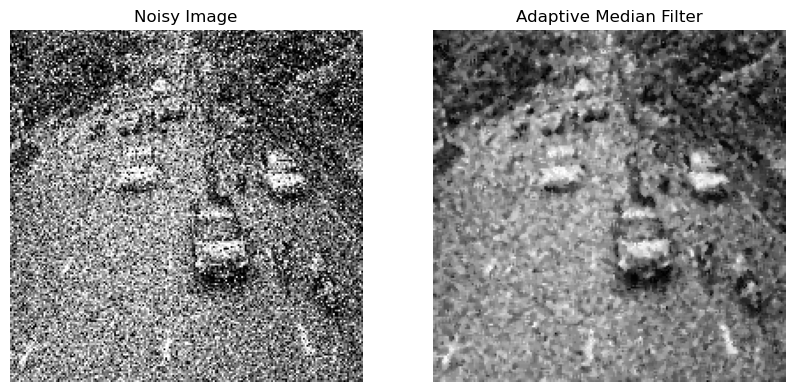

In [9]:

    plt.figure(figsize=(10, 5))

    plt.subplot(121), plt.imshow(noisy_image, cmap='gray')
    plt.title('Noisy Image'), plt.axis('off')

    plt.subplot(122), plt.imshow(adaptive_median_filtered, cmap='gray')
    plt.title('Adaptive Median Filter'), plt.axis('off')

    plt.show()